In [9]:
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

# ---------------- DATASET 1 ----------------
data1 = {
    'Outlook': ['Sunny','Sunny','Overcast','Rain','Rain','Rain','Overcast','Sunny','Sunny','Rain','Sunny','Overcast','Overcast','Rain'],
    'Temperature': ['Hot','Hot','Hot','Mild','Cool','Cool','Cool','Mild','Cool','Mild','Mild','Mild','Hot','Mild'],
    'Humidity': ['High','High','High','High','Normal','Normal','Normal','High','Normal','Normal','Normal','High','Normal','High'],
    'Wind': ['Weak','Strong','Weak','Weak','Weak','Strong','Strong','Weak','Weak','Weak','Strong','Strong','Weak','Strong'],
    'PlayTennis': ['No','No','Yes','Yes','Yes','No','Yes','No','Yes','Yes','Yes','Yes','Yes','No']
}

# ---------------- DATASET 2 ----------------
data2 = {
    'StudyTime': ['High','Low','Medium','High','Low','Medium','High','Low','Medium','High'],
    'Attendance': ['Good','Poor','Good','Good','Poor','Good','Good','Poor','Good','Good'],
    'Assignment': ['Yes','No','Yes','Yes','No','Yes','Yes','No','Yes','Yes'],
    'Result': ['Pass','Fail','Pass','Pass','Fail','Pass','Pass','Fail','Pass','Pass']
}


def evaluate_dataset(data, target):

    df = pd.DataFrame(data)

    X = df.drop(columns=[target])
    y = df[target]

    # Encode categorical values
    le = LabelEncoder()
    for col in X.columns:
        X[col] = le.fit_transform(X[col])

    y = le.fit_transform(y)

    # Split dataset
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=1
    )

    # ID3 uses entropy
    model = DecisionTreeClassifier(criterion="entropy")

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    print("Accuracy :", accuracy_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred))
    print("Recall   :", recall_score(y_test, y_pred))
    print("F1 Score :", f1_score(y_test, y_pred))
    print("----------------------------")


print("DATASET 1 (PlayTennis)")
evaluate_dataset(data1, 'PlayTennis')

print("DATASET 2 (Student Result)")
evaluate_dataset(data2, 'Result')

DATASET 1 (PlayTennis)
Accuracy : 0.4
Precision: 1.0
Recall   : 0.25
F1 Score : 0.4
----------------------------
DATASET 2 (Student Result)
Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1 Score : 1.0
----------------------------


In [10]:
import pandas as pd
import numpy as np
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

# ---------------- DATASET 1 ----------------
# House Price Dataset
data1 = {
    "Size":[1000,1200,1500,1800,2000,2200,2500,2700],
    "Bedrooms":[2,2,3,3,4,4,4,5],
    "Age":[10,8,6,5,4,3,2,1],
    "Price":[200,220,260,300,320,360,400,420]
}

# ---------------- DATASET 2 ----------------
# Student Score Dataset
data2 = {
    "StudyHours":[1,2,3,4,5,6,7,8],
    "SleepHours":[7,6,6,7,8,6,7,8],
    "Attendance":[60,65,70,75,80,85,90,95],
    "Score":[40,45,50,55,65,70,80,90]
}

def evaluate_regression(data, target):

    df = pd.DataFrame(data)

    X = df.drop(columns=[target])
    y = df[target]

    # Split dataset
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=1
    )

    # CART Regression Tree
    model = DecisionTreeRegressor()

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    # Metrics
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    return mae, mse, rmse, r2


# Evaluate Dataset 1
mae1, mse1, rmse1, r21 = evaluate_regression(data1, "Price")

# Evaluate Dataset 2
mae2, mse2, rmse2, r22 = evaluate_regression(data2, "Score")


print("------ DATASET 1 : House Price ------")
print("MAE :", mae1)
print("MSE :", mse1)
print("RMSE:", rmse1)
print("R2 Score:", r21)

print("\n------ DATASET 2 : Student Score ------")
print("MAE :", mae2)
print("MSE :", mse2)
print("RMSE:", rmse2)
print("R2 Score:", r22)


print("\n------ COMPARISON ------")
print("Dataset 1 vs Dataset 2")
print("MAE :", mae1, "vs", mae2)
print("MSE :", mse1, "vs", mse2)
print("RMSE:", rmse1, "vs", rmse2)
print("R2 Score:", r21, "vs", r22)

------ DATASET 1 : House Price ------
MAE : 26.666666666666668
MSE : 800.0
RMSE: 28.284271247461902
R2 Score: 0.8928571428571429

------ DATASET 2 : Student Score ------
MAE : 6.666666666666667
MSE : 50.0
RMSE: 7.0710678118654755
R2 Score: 0.8767123287671232

------ COMPARISON ------
Dataset 1 vs Dataset 2
MAE : 26.666666666666668 vs 6.666666666666667
MSE : 800.0 vs 50.0
RMSE: 28.284271247461902 vs 7.0710678118654755
R2 Score: 0.8928571428571429 vs 0.8767123287671232


Dataset 1 Metrics: 26.666666666666668 800.0 28.284271247461902 0.8928571428571429
Dataset 2 Metrics: 6.666666666666667 50.0 7.0710678118654755 0.8767123287671232


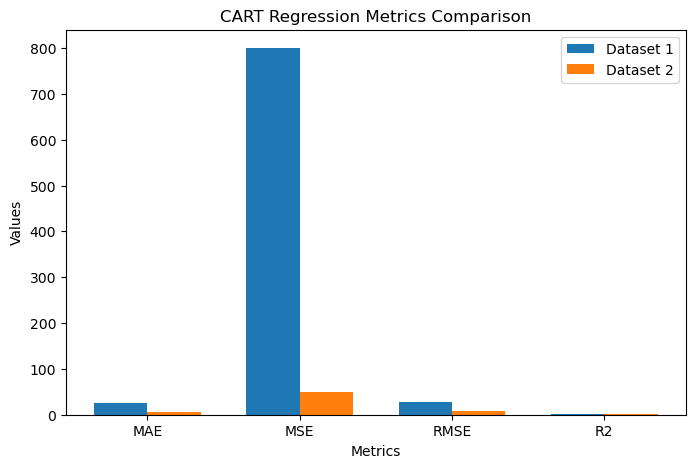

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

# ---------------- DATASET 1 ----------------
data1 = {
    "Size":[1000,1200,1500,1800,2000,2200,2500,2700],
    "Bedrooms":[2,2,3,3,4,4,4,5],
    "Age":[10,8,6,5,4,3,2,1],
    "Price":[200,220,260,300,320,360,400,420]
}

# ---------------- DATASET 2 ----------------
data2 = {
    "StudyHours":[1,2,3,4,5,6,7,8],
    "SleepHours":[7,6,6,7,8,6,7,8],
    "Attendance":[60,65,70,75,80,85,90,95],
    "Score":[40,45,50,55,65,70,80,90]
}

def evaluate_regression(data, target):

    df = pd.DataFrame(data)

    X = df.drop(columns=[target])
    y = df[target]

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=1
    )

    model = DecisionTreeRegressor()
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    return mae, mse, rmse, r2


# Evaluate both datasets
mae1, mse1, rmse1, r21 = evaluate_regression(data1, "Price")
mae2, mse2, rmse2, r22 = evaluate_regression(data2, "Score")

print("Dataset 1 Metrics:", mae1, mse1, rmse1, r21)
print("Dataset 2 Metrics:", mae2, mse2, rmse2, r22)

# ---------------- GRAPH COMPARISON ----------------
metrics = ["MAE", "MSE", "RMSE", "R2"]
dataset1_values = [mae1, mse1, rmse1, r21]
dataset2_values = [mae2, mse2, rmse2, r22]

x = np.arange(len(metrics))
width = 0.35

plt.figure(figsize=(8,5))
plt.bar(x - width/2, dataset1_values, width, label="Dataset 1")
plt.bar(x + width/2, dataset2_values, width, label="Dataset 2")

plt.xlabel("Metrics")
plt.ylabel("Values")
plt.title("CART Regression Metrics Comparison")
plt.xticks(x, metrics)
plt.legend()

plt.show()


 Dataset 1 (House Price)
MAE : 26.666666666666668
MSE : 800.0
RMSE: 28.284271247461902
R2 Score: 0.8928571428571429


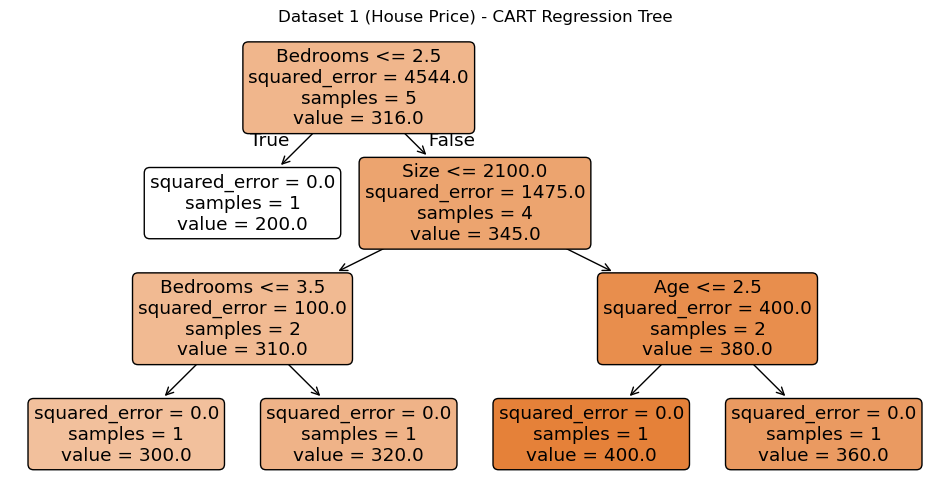


 Dataset 2 (Student Score)
MAE : 6.666666666666667
MSE : 50.0
RMSE: 7.0710678118654755
R2 Score: 0.8767123287671232


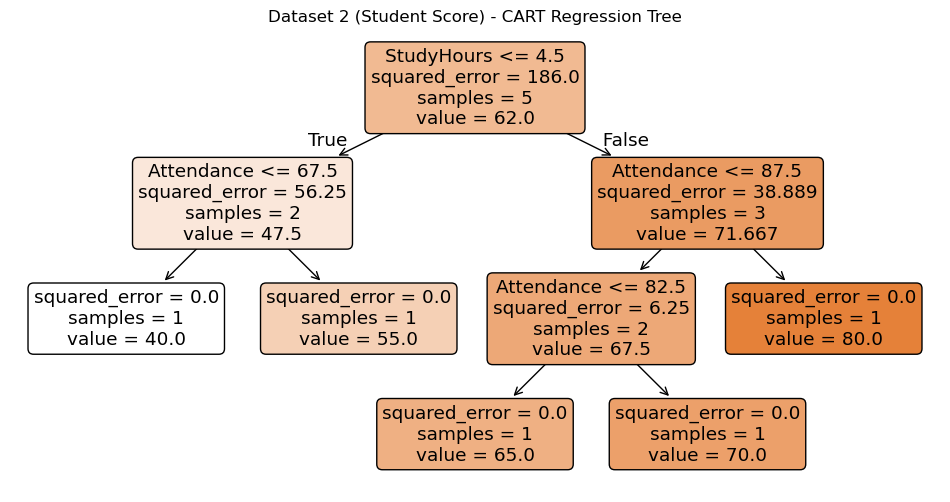

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

# ---------------- DATASET 1 ----------------
data1 = {
    "Size":[1000,1200,1500,1800,2000,2200,2500,2700],
    "Bedrooms":[2,2,3,3,4,4,4,5],
    "Age":[10,8,6,5,4,3,2,1],
    "Price":[200,220,260,300,320,360,400,420]
}

# ---------------- DATASET 2 ----------------
data2 = {
    "StudyHours":[1,2,3,4,5,6,7,8],
    "SleepHours":[7,6,6,7,8,6,7,8],
    "Attendance":[60,65,70,75,80,85,90,95],
    "Score":[40,45,50,55,65,70,80,90]
}

def evaluate_regression(data, target, title):

    df = pd.DataFrame(data)

    X = df.drop(columns=[target])
    y = df[target]

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=1
    )

    model = DecisionTreeRegressor()
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    print("\n", title)
    print("MAE :", mae)
    print("MSE :", mse)
    print("RMSE:", rmse)
    print("R2 Score:", r2)

    # -------- Visual Tree --------
    plt.figure(figsize=(12,6))
    plot_tree(model,
              feature_names=X.columns,
              filled=True,
              rounded=True)

    plt.title(title + " - CART Regression Tree")
    plt.show()


# Run both datasets
evaluate_regression(data1, "Price", "Dataset 1 (House Price)")
evaluate_regression(data2, "Score", "Dataset 2 (Student Score)")


 Dataset 1 (Play Tennis)
Accuracy : 0.4
Precision: 1.0
Recall   : 0.25
F1 Score : 0.4


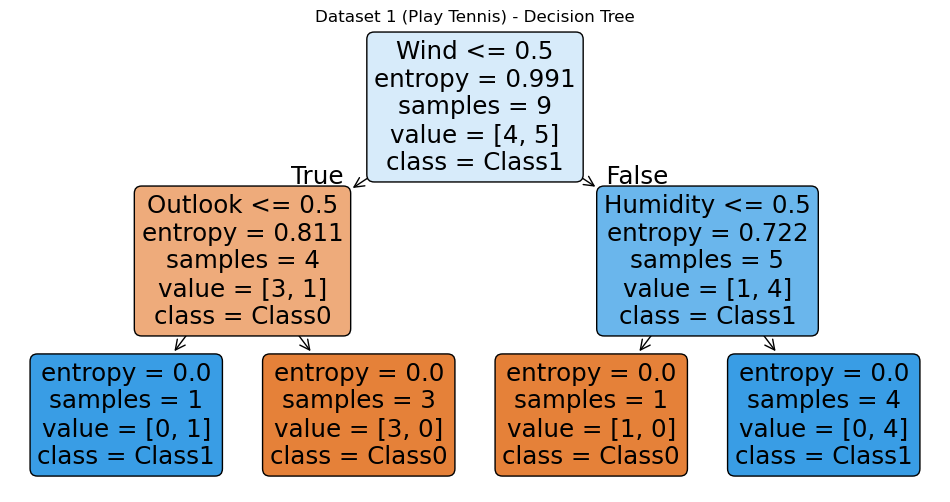


 Dataset 2 (Student Result)
Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1 Score : 1.0


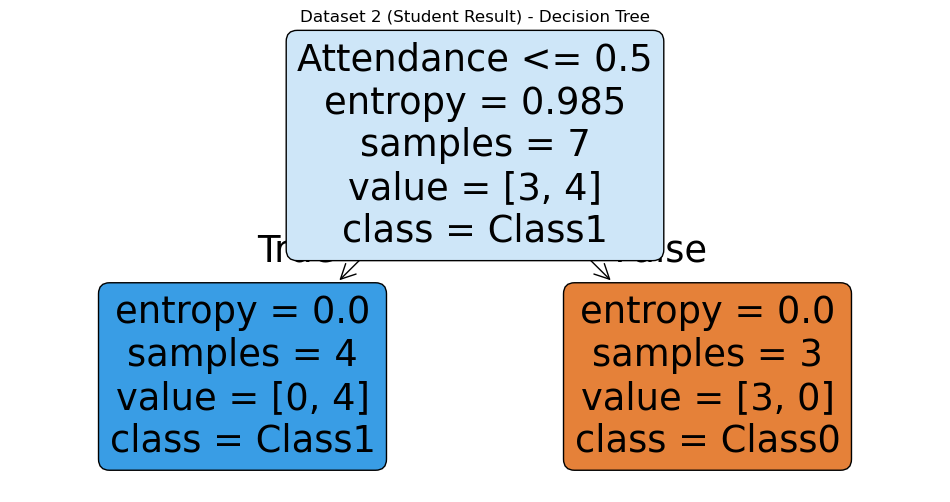

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

# ---------------- DATASET 1 ----------------
data1 = {
    'Outlook': ['Sunny','Sunny','Overcast','Rain','Rain','Rain','Overcast','Sunny','Sunny','Rain','Sunny','Overcast','Overcast','Rain'],
    'Temperature': ['Hot','Hot','Hot','Mild','Cool','Cool','Cool','Mild','Cool','Mild','Mild','Mild','Hot','Mild'],
    'Humidity': ['High','High','High','High','Normal','Normal','Normal','High','Normal','Normal','Normal','High','Normal','High'],
    'Wind': ['Weak','Strong','Weak','Weak','Weak','Strong','Strong','Weak','Weak','Weak','Strong','Strong','Weak','Strong'],
    'PlayTennis': ['No','No','Yes','Yes','Yes','No','Yes','No','Yes','Yes','Yes','Yes','Yes','No']
}

# ---------------- DATASET 2 ----------------
data2 = {
    'StudyTime': ['High','Low','Medium','High','Low','Medium','High','Low','Medium','High'],
    'Attendance': ['Good','Poor','Good','Good','Poor','Good','Good','Poor','Good','Good'],
    'Assignment': ['Yes','No','Yes','Yes','No','Yes','Yes','No','Yes','Yes'],
    'Result': ['Pass','Fail','Pass','Pass','Fail','Pass','Pass','Fail','Pass','Pass']
}

def evaluate_dataset(data, target, title):

    df = pd.DataFrame(data)

    X = df.drop(columns=[target])
    y = df[target]

    # Encode categorical data
    le = LabelEncoder()
    for col in X.columns:
        X[col] = le.fit_transform(X[col])

    y = le.fit_transform(y)

    # Train test split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=1
    )

    # ID3 uses entropy
    model = DecisionTreeClassifier(criterion="entropy")

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    print("\n", title)
    print("Accuracy :", accuracy_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred))
    print("Recall   :", recall_score(y_test, y_pred))
    print("F1 Score :", f1_score(y_test, y_pred))

    # -------- Visual Tree --------
    plt.figure(figsize=(12,6))
    plot_tree(model,
              feature_names=X.columns,
              class_names=["Class0","Class1"],
              filled=True,
              rounded=True)

    plt.title(title + " - Decision Tree")
    plt.show()


# Run both datasets
evaluate_dataset(data1, 'PlayTennis', "Dataset 1 (Play Tennis)")
evaluate_dataset(data2, 'Result', "Dataset 2 (Student Result)")

ID3 Decision Tree (with entropy=0 stopping):
{'Outlook': {'Sunny': {'Humidity': {'High': 'No', 'Normal': 'Yes'}}, 'Overcast': 'Yes', 'Rain': {'Wind': {'Weak': 'Yes', 'Strong': 'No'}}}}


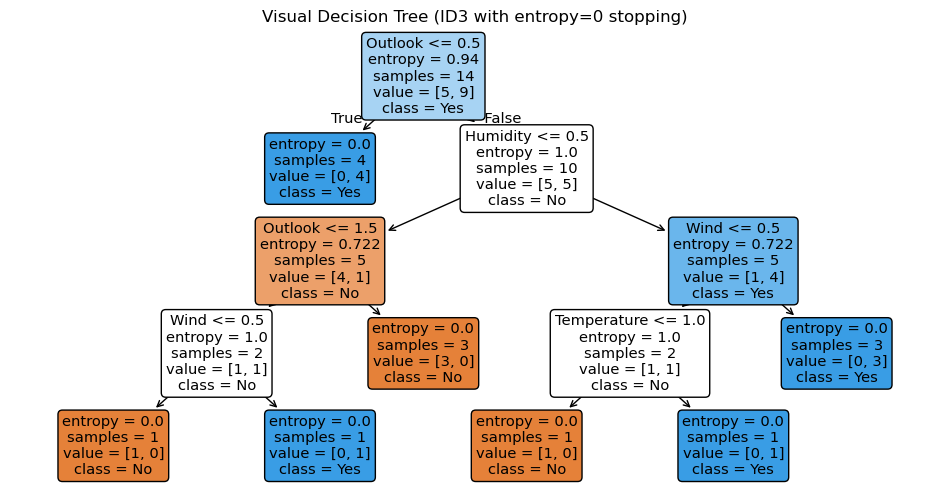

In [14]:
import pandas as pd
import math
from collections import Counter
import matplotlib.pyplot as plt
from sklearn import tree

# ---------------- DATASET ----------------
data = {
    'Outlook': ['Sunny','Sunny','Overcast','Rain','Rain','Rain','Overcast','Sunny','Sunny','Rain','Sunny','Overcast','Overcast','Rain'],
    'Temperature': ['Hot','Hot','Hot','Mild','Cool','Cool','Cool','Mild','Cool','Mild','Mild','Mild','Hot','Mild'],
    'Humidity': ['High','High','High','High','Normal','Normal','Normal','High','Normal','Normal','Normal','High','Normal','High'],
    'Wind': ['Weak','Strong','Weak','Weak','Weak','Strong','Strong','Weak','Weak','Weak','Strong','Strong','Weak','Strong'],
    'PlayTennis': ['No','No','Yes','Yes','Yes','No','Yes','No','Yes','Yes','Yes','Yes','Yes','No']
}

df = pd.DataFrame(data)

# ---------------- ENTROPY ----------------
def entropy(target_col):
    counts = Counter(target_col)
    total = len(target_col)
    ent = 0
    for count in counts.values():
        p = count / total
        if p > 0:
            ent -= p * math.log2(p)
    return ent

# ---------------- INFORMATION GAIN ----------------
def info_gain(data, attribute, target):
    total_entropy = entropy(data[target])
    values = data[attribute].unique()
    
    weighted_entropy = 0
    for v in values:
        subset = data[data[attribute] == v]
        weighted_entropy += (len(subset)/len(data)) * entropy(subset[target])
        
    return total_entropy - weighted_entropy

# ---------------- ID3 ALGORITHM ----------------
def id3(data, features, target, parent_class=None):
    # If all examples have same class, entropy = 0 → stop
    if entropy(data[target]) == 0:
        return data[target].iloc[0]  # leaf node
    
    # If no features left, return majority class
    if len(features) == 0:
        return parent_class
    
    parent_class = Counter(data[target]).most_common(1)[0][0]
    
    # Select best attribute using Information Gain
    gains = [info_gain(data, f, target) for f in features]
    best_attr = features[gains.index(max(gains))]
    
    tree_dict = {best_attr:{}}
    
    remaining_features = [f for f in features if f != best_attr]
    
    for value in data[best_attr].unique():
        subset = data[data[best_attr] == value]
        if subset.empty:
            tree_dict[best_attr][value] = parent_class
        else:
            subtree = id3(subset, remaining_features, target, parent_class)
            tree_dict[best_attr][value] = subtree
            
    return tree_dict

# ---------------- BUILD TREE ----------------
features = df.columns[:-1]
decision_tree = id3(df, features, 'PlayTennis')

print("ID3 Decision Tree (with entropy=0 stopping):")
print(decision_tree)

# ---------------- VISUALIZATION USING sklearn ----------------
# Encode categorical features for sklearn visualization
from sklearn.preprocessing import LabelEncoder
X = df.drop('PlayTennis', axis=1)
y = df['PlayTennis']

for col in X.columns:
    X[col] = LabelEncoder().fit_transform(X[col])
y = LabelEncoder().fit_transform(y)

clf = tree.DecisionTreeClassifier(criterion='entropy')
clf = clf.fit(X, y)

plt.figure(figsize=(12,6))
tree.plot_tree(clf, feature_names=X.columns, class_names=['No','Yes'], filled=True, rounded=True)
plt.title("Visual Decision Tree (ID3 with entropy=0 stopping)")
plt.show()